# Task 1: MNIST Classification Models Demo with Hyperparameter Tuning

This notebook demonstrates the `MnistClassifier` usage. It includes hyperparameter tuning via Random Search, evaluation using `torchmetrics`, and visualization of the tuning process using `matplotlib` and `seaborn`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from sklearn.model_selection import ParameterSampler
from torchmetrics import Accuracy, Precision, Recall, F1Score
from torchvision import datasets

from models.mnist_classifier import MnistClassifier

sns.set_theme(style="whitegrid")

train_dataset = datasets.MNIST(root='./data', train=True, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, download=True)

x_train_full = train_dataset.data.numpy().astype(np.float32) / 255.0
y_train_full = train_dataset.targets.numpy()
x_test = test_dataset.data.numpy().astype(np.float32) / 255.0
y_test = test_dataset.targets.numpy()

x_train = x_train_full[:1000]
y_train = y_train_full[:1000]

x_val = x_train_full[1000:1200]
y_val = y_train_full[1000:1200]

x_test = x_test[:200]
y_test = y_test[:200]

In [2]:
accuracy_metric = Accuracy(task='multiclass', num_classes=10)
precision_metric = Precision(task='multiclass', num_classes=10, average='macro')
recall_metric = Recall(task='multiclass', num_classes=10, average='macro')
f1_metric = F1Score(task='multiclass', num_classes=10, average='macro')

def evaluate_metrics(preds, targets):
    preds_t = torch.tensor(preds)
    targets_t = torch.tensor(targets)

    acc = accuracy_metric(preds_t, targets_t).item()
    prec = precision_metric(preds_t, targets_t).item()
    rec = recall_metric(preds_t, targets_t).item()
    f1 = f1_metric(preds_t, targets_t).item()

    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}\n")
    return acc

def plot_tuning_results(params_list, scores, model_name):
    plt.figure(figsize=(10, 5))
    param_labels = [str(p) for p in params_list]
    sns.lineplot(x=param_labels, y=scores, marker='o', linewidth=2, markersize=8)
    plt.xticks(rotation=15)
    plt.title(f'{model_name} - Random Search Optimization')
    plt.xlabel('Hyperparameter Combinations')
    plt.ylabel('Validation Accuracy')
    plt.tight_layout()
    plt.show()

## 1. Random Forest Tuning

Accuracy:  0.7500
Precision: 0.7537
Recall:    0.7408
F1 Score:  0.7394

Accuracy:  0.8650
Precision: 0.8602
Recall:    0.8590
F1 Score:  0.8561

Accuracy:  0.8650
Precision: 0.8644
Recall:    0.8595
F1 Score:  0.8608



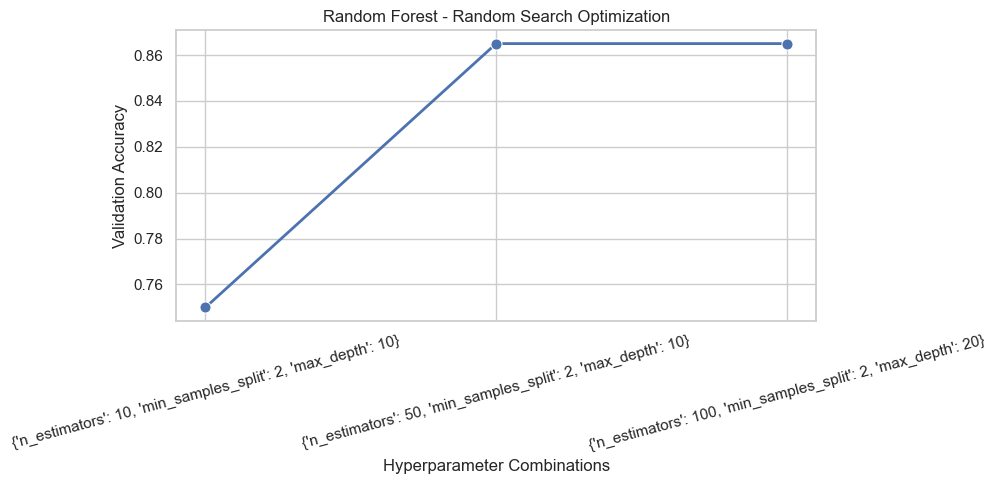

--- Final Random Forest Test Results ---
Accuracy:  0.9600
Precision: 0.9589
Recall:    0.9625
F1 Score:  0.9603



0.9599999785423279

In [3]:
rf_param_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
rf_sampler = list(ParameterSampler(rf_param_grid, n_iter=3, random_state=42))
rf_scores = []

for params in rf_sampler:
    rf_model = MnistClassifier(algorithm='rf', **params)
    rf_model.train(x_train, y_train)
    preds = rf_model.predict(x_val)
    score = evaluate_metrics(preds, y_val)
    rf_scores.append(score)

plot_tuning_results(rf_sampler, rf_scores, "Random Forest")

best_rf_params = rf_sampler[np.argmax(rf_scores)]
best_rf = MnistClassifier(algorithm='rf', **best_rf_params)
best_rf.train(x_train_full, y_train_full)
rf_test_preds = best_rf.predict(x_test)

print("--- Final Random Forest Test Results ---")
evaluate_metrics(rf_test_preds, y_test)

## 2. Feed-Forward Neural Network Tuning

Epoch 0: Training loss: 0.03609672451019287
Epoch 1: Training loss: 0.03264280152320862
Epoch 2: Training loss: 0.026983807921409607
Accuracy:  0.0850
Precision: 0.0714
Recall:    0.0806
F1 Score:  0.0746

Epoch 0: Training loss: 0.01819398808479309
Epoch 1: Training loss: 0.01720050644874573
Epoch 2: Training loss: 0.015588689208030701
Accuracy:  0.0700
Precision: 0.0465
Recall:    0.0618
F1 Score:  0.0511

Epoch 0: Training loss: 0.03586067152023315
Epoch 1: Training loss: 0.031298759937286376
Accuracy:  0.1300
Precision: 0.1161
Recall:    0.1135
F1 Score:  0.1022



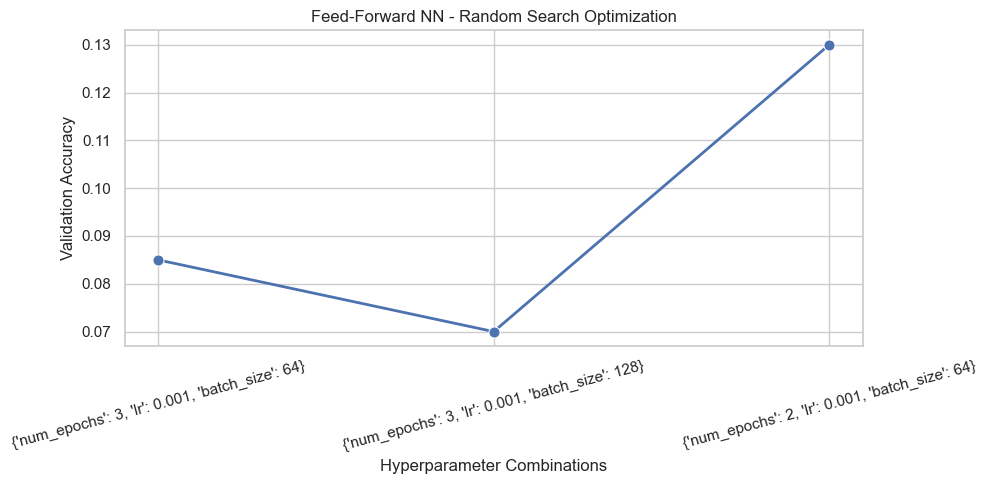

Epoch 0: Training loss: 0.009519128034760554
Epoch 1: Training loss: 0.005013842486341794
--- Final Feed-Forward NN Test Results ---
Accuracy:  0.1050
Precision: 0.0968
Recall:    0.0975
F1 Score:  0.0970



0.10499999672174454

In [4]:
nn_param_grid = {
    'lr': [0.001, 0.01],
    'batch_size': [64, 128],
    'num_epochs': [2, 3]
}
nn_sampler = list(ParameterSampler(nn_param_grid, n_iter=3, random_state=42))
nn_scores = []

for params in nn_sampler:
    nn_model = MnistClassifier(algorithm='ffn', **params)
    nn_model.train(x_train, y_train)
    preds = nn_model.predict(x_val)
    score = evaluate_metrics(preds, y_val)
    nn_scores.append(score)

plot_tuning_results(nn_sampler, nn_scores, "Feed-Forward NN")

best_nn_params = nn_sampler[np.argmax(nn_scores)]
best_nn = MnistClassifier(algorithm='ffn', **best_nn_params)
best_nn.train(x_train_full, y_train_full)
nn_test_preds = best_nn.predict(x_test)

print("--- Final Feed-Forward NN Test Results ---")
evaluate_metrics(nn_test_preds, y_test)

## 3. Convolutional Neural Network Tuning

CNN Epoch 0, loss: 1.9967061338424683
CNN Epoch 1, loss: 0.6478750739097595
CNN Epoch 2, loss: 0.5786024700403214
Accuracy:  0.1150
Precision: 0.1167
Recall:    0.1153
F1 Score:  0.1156

CNN Epoch 0, loss: 2.8943039975166323
CNN Epoch 1, loss: 0.932094398021698
CNN Epoch 2, loss: 0.6673176329135895
Accuracy:  0.0900
Precision: 0.0807
Recall:    0.0824
F1 Score:  0.0811



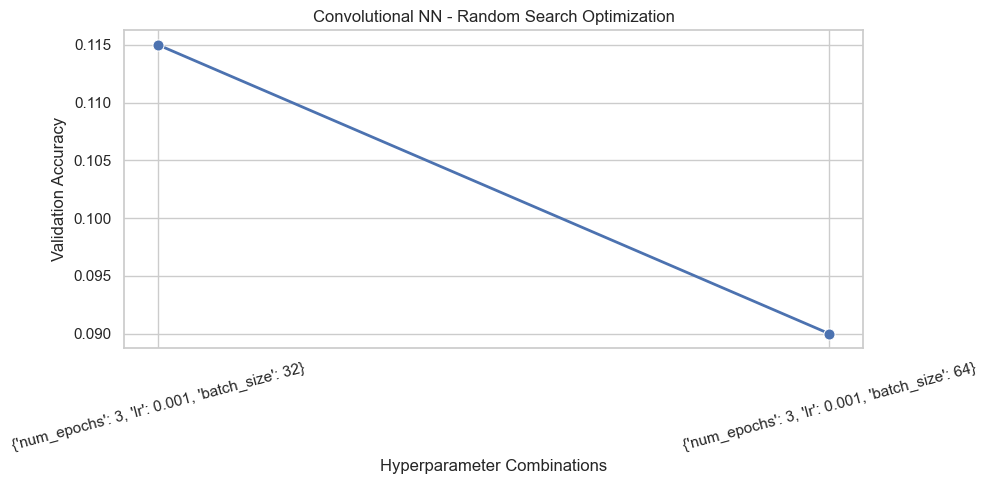

CNN Epoch 0, loss: 0.4164720185915629
CNN Epoch 1, loss: 0.23623162506868442
CNN Epoch 2, loss: 0.1886910579248021
--- Final Convolutional NN Test Results ---
Accuracy:  0.0700
Precision: 0.0631
Recall:    0.0631
F1 Score:  0.0631



0.07000000029802322

In [5]:
cnn_param_grid = {
    'lr': [0.001, 0.005],
    'batch_size': [32, 64],
    'num_epochs': [2, 3]
}
cnn_sampler = list(ParameterSampler(cnn_param_grid, n_iter=2, random_state=42))
cnn_scores = []

for params in cnn_sampler:
    cnn_model = MnistClassifier(algorithm='cnn', **params)
    cnn_model.train(x_train, y_train)
    preds = cnn_model.predict(x_val)
    score = evaluate_metrics(preds, y_val)
    cnn_scores.append(score)

plot_tuning_results(cnn_sampler, cnn_scores, "Convolutional NN")

best_cnn_params = cnn_sampler[np.argmax(cnn_scores)]
best_cnn = MnistClassifier(algorithm='cnn', **best_cnn_params)
best_cnn.train(x_train_full, y_train_full)
cnn_test_preds = best_cnn.predict(x_test)

print("--- Final Convolutional NN Test Results ---")
evaluate_metrics(cnn_test_preds, y_test)

## Edge Cases

Description of edge cases:
1. Unknown algorithm passed to the classifier.
2. Invalid input dimensions passed during prediction.

In [6]:
try:
    wrong_classifier = MnistClassifier(algorithm='svm')
except Exception as e:
    print(f"Caught Exception: {type(e).__name__}: {e}")

try:
    bad_x_test = np.random.rand(10, 700)
    best_cnn.predict(bad_x_test)
except Exception as e:
    print(f"Caught Exception: {type(e).__name__}: {e}")

Caught Exception: ValueError: Algorithm svm is not implemented. Choose from: "rf", "ffn", "cnn".
Caught Exception: ValueError: cannot reshape array of size 7000 into shape (1,28,28)
